# Понижение размерности

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_circles, load_breast_cancer
%matplotlib inline

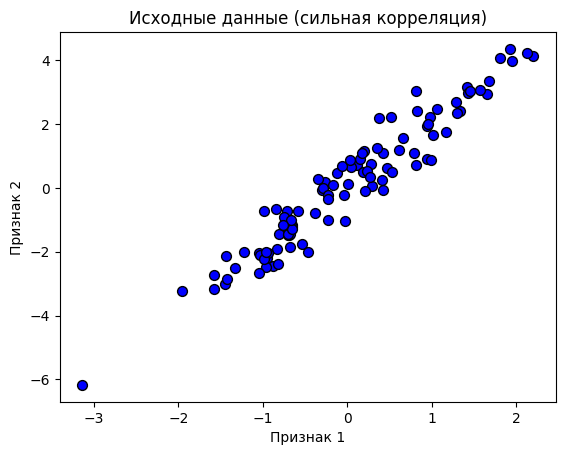

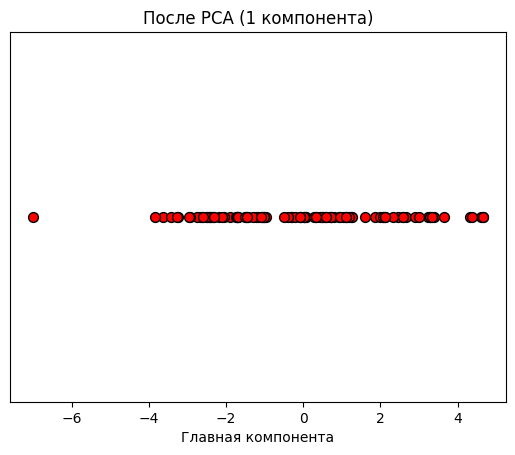

Главная компонента (направление): [[0.4340205 0.900903 ]]
Объясненная дисперсия: [0.98878865]


In [2]:
# Генерация данных
n_samples = 100
x = np.random.normal(0, 1, n_samples)
y = 2 * x + np.random.normal(0, 0.5, n_samples)
X = np.column_stack((x, y))

# Исходный график
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k', s=50)
plt.title('Исходные данные (сильная корреляция)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.show()

# PCA до 1 компоненты
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

# Визуализация после понижения размерности
plt.scatter(X_pca, np.zeros_like(X_pca), c='red', edgecolor='k', s=50)
plt.title('После PCA (1 компонента)')
plt.xlabel('Главная компонента')
plt.yticks([])
plt.show()

print(f"Главная компонента (направление): {pca.components_}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_}")

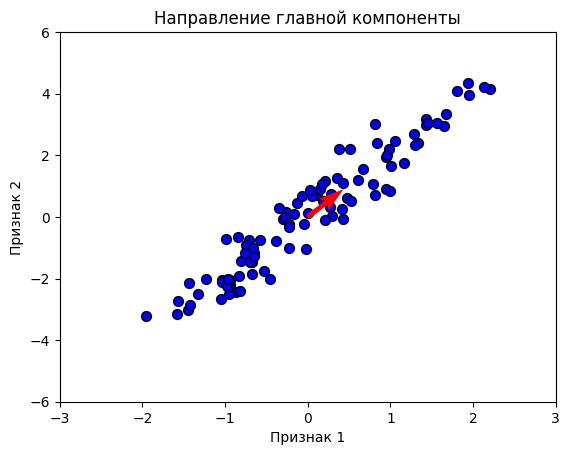

In [3]:
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k', s=50)
pc1_direction = pca.components_[0]
plt.quiver(0, 0, pc1_direction[0], pc1_direction[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)
plt.title('Направление главной компоненты')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.xlim(-3, 3)
plt.ylim(-6, 6)
plt.show()

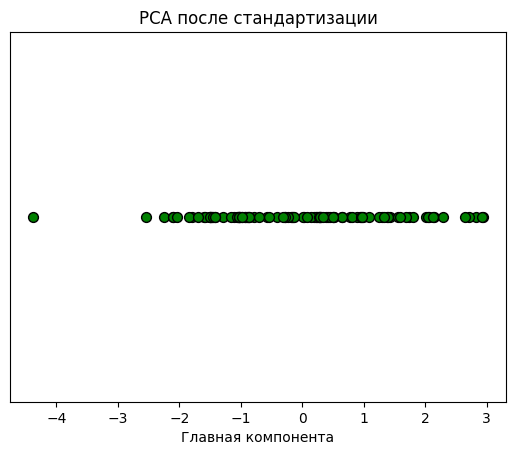

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_scaled = PCA(n_components=1)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

plt.scatter(X_pca_scaled, np.zeros_like(X_pca_scaled), c='green', edgecolor='k', s=50)
plt.title('PCA после стандартизации')
plt.xlabel('Главная компонента')
plt.yticks([])
plt.show()

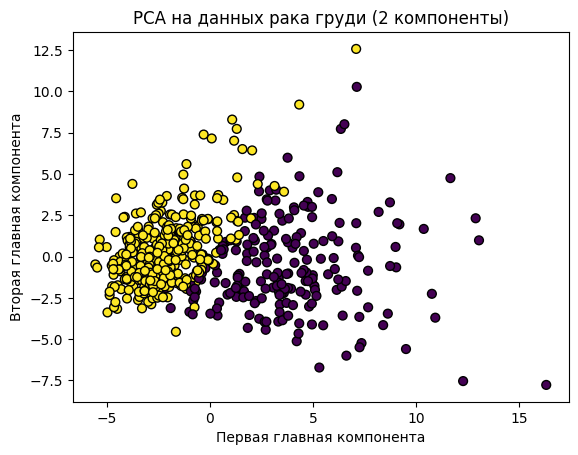

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182]
Суммарная объясненная дисперсия: 0.63


In [5]:
data = load_breast_cancer()
X = data.data
y = data.target

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA до 2 компонент
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Визуализация
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=40)
plt.title('PCA на данных рака груди (2 компоненты)')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.show()

print(f"Объясненная дисперсия каждой компоненты: {pca.explained_variance_ratio_}")
print(f"Суммарная объясненная дисперсия: {sum(pca.explained_variance_ratio_):.2f}")

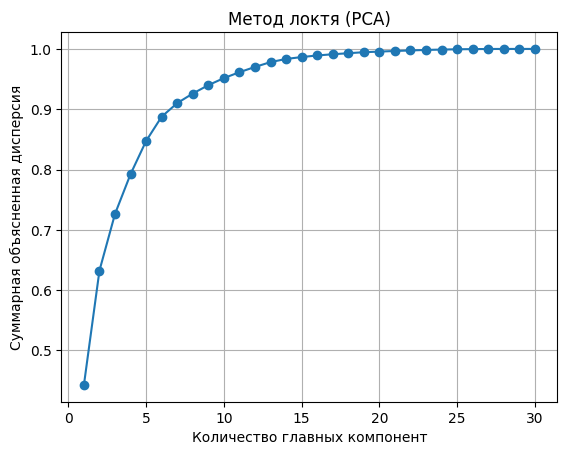

In [7]:
n_components_range = range(1, 31)
explained_variance = []

for n in n_components_range:
    pca = PCA(n_components=n)
    pca.fit(X_scaled)
    explained_variance.append(sum(pca.explained_variance_ratio_))

plt.plot(n_components_range, explained_variance, marker='o')
plt.xlabel('Количество главных компонент')
plt.ylabel('Суммарная объясненная дисперсия')
plt.title('Метод локтя (PCA)')
plt.grid(True)
plt.show()

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734]
Суммарная объясненная дисперсия: 0.91


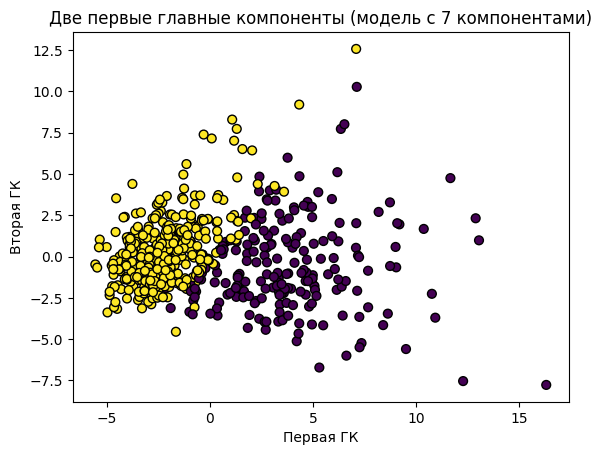

In [8]:
pca_opt = PCA(n_components=7)
X_pca_opt = pca_opt.fit_transform(X_scaled)

print(f"Объясненная дисперсия каждой компоненты: {pca_opt.explained_variance_ratio_}")
print(f"Суммарная объясненная дисперсия: {sum(pca_opt.explained_variance_ratio_):.2f}")

# Две первые компоненты (они те же, что и в блоке 5)
plt.scatter(X_pca_opt[:, 0], X_pca_opt[:, 1], c=y, cmap='viridis', edgecolor='k', s=40)
plt.title('Две первые главные компоненты (модель с 7 компонентами)')
plt.xlabel('Первая ГК')
plt.ylabel('Вторая ГК')
plt.show()

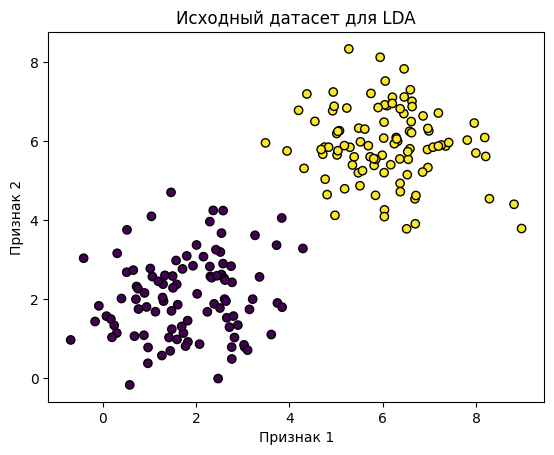

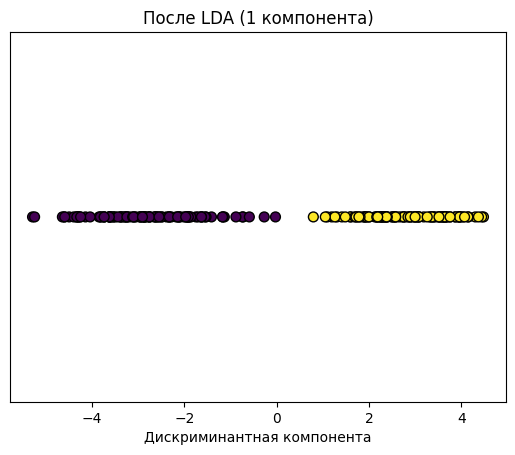

Коэффициенты LDA: [[9.02142038 8.61078157]]


In [9]:
n_samples = 100
x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(6, 1, n_samples)
y2 = np.random.normal(6, 1, n_samples)

X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Исходный график
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.title('Исходный датасет для LDA')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.show()

# LDA до 1 компоненты
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

# Визуализация
plt.scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='viridis', edgecolor='k', s=50)
plt.title('После LDA (1 компонента)')
plt.xlabel('Дискриминантная компонента')
plt.yticks([])
plt.show()

print(f"Коэффициенты LDA: {lda.coef_}")

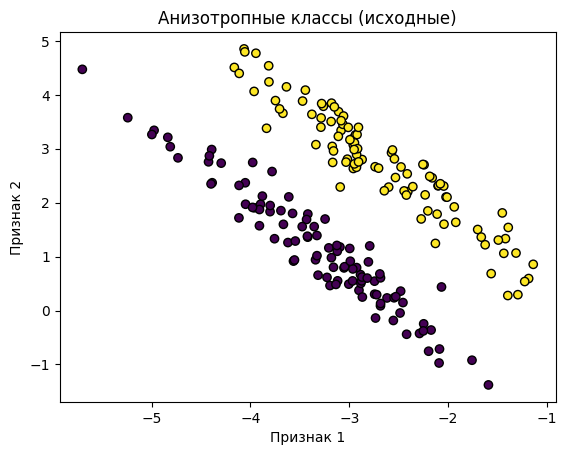

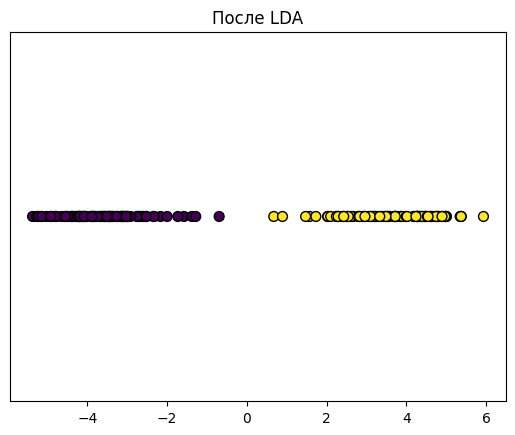

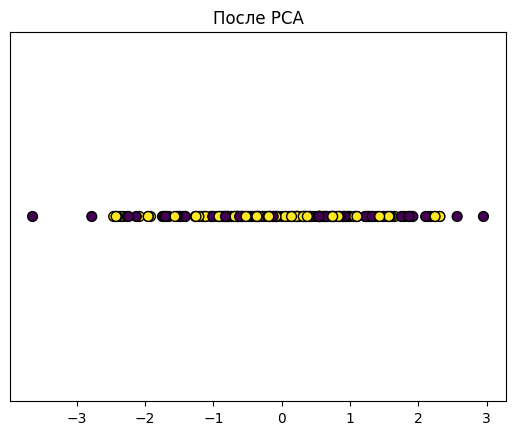

In [10]:
X, y = make_blobs(n_samples=200, random_state=170, centers=2)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X = np.dot(X, transformation)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Исходный график
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.title('Анизотропные классы (исходные)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.show()

# LDA
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)
plt.scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='viridis', edgecolor='k', s=50)
plt.title('После LDA')
plt.yticks([])
plt.show()

# PCA
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca, np.zeros_like(X_pca), c=y, cmap='viridis', edgecolor='k', s=50)
plt.title('После PCA')
plt.yticks([])
plt.show()

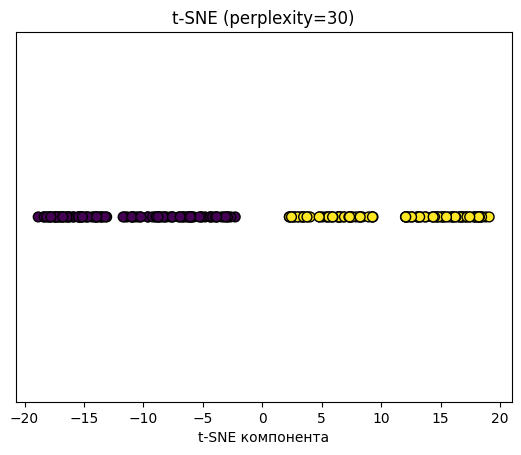

In [11]:
# Используем те же данные, что в блоке 8 (X, y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(n_components=1, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne, np.zeros_like(X_tsne), c=y, cmap='viridis', edgecolor='k', s=50)
plt.title('t‑SNE (perplexity=30)')
plt.xlabel('t‑SNE компонента')
plt.yticks([])
plt.show()

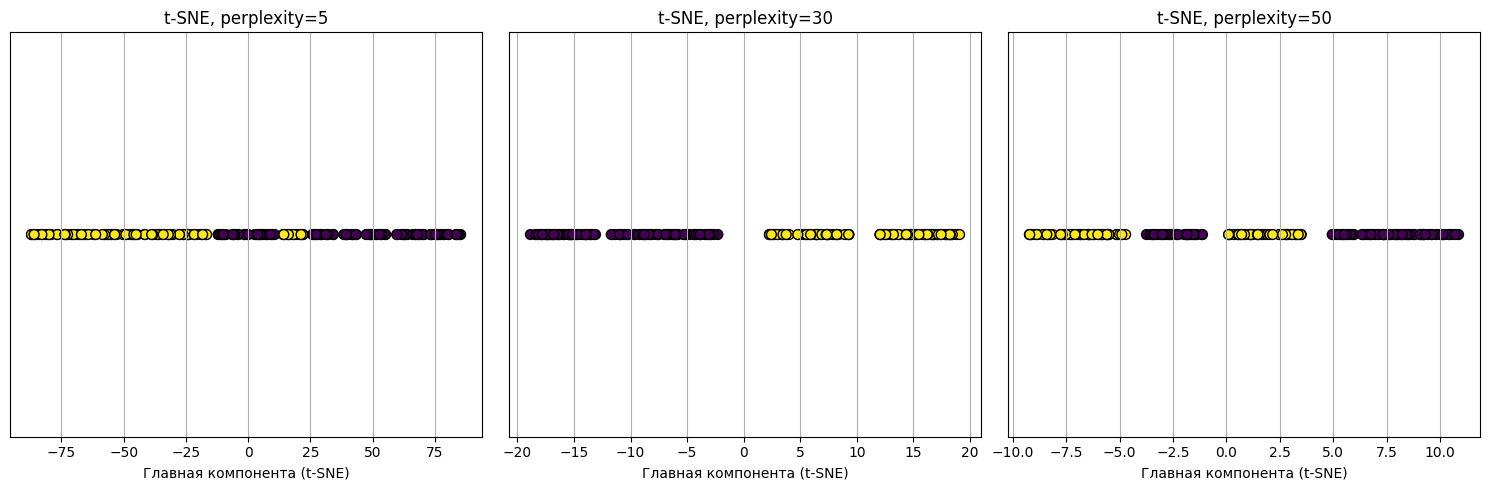

In [12]:
perplexity_values = [5, 30, 50]
plt.figure(figsize=(15, 5))

for i, perplexity in enumerate(perplexity_values):
    tsne = TSNE(n_components=1, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    plt.subplot(1, 3, i+1)
    plt.scatter(X_tsne, np.zeros_like(X_tsne), c=y, cmap='viridis', edgecolor='k', s=50)
    plt.title(f't‑SNE, perplexity={perplexity}')
    plt.xlabel('Главная компонента (t‑SNE)')
    plt.yticks([])
    plt.grid(True)
plt.tight_layout()
plt.show()

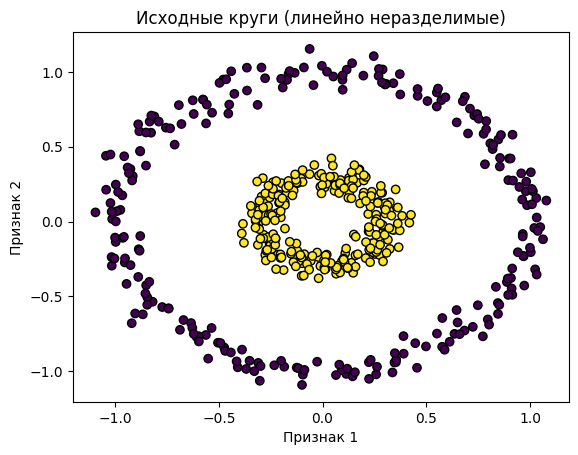

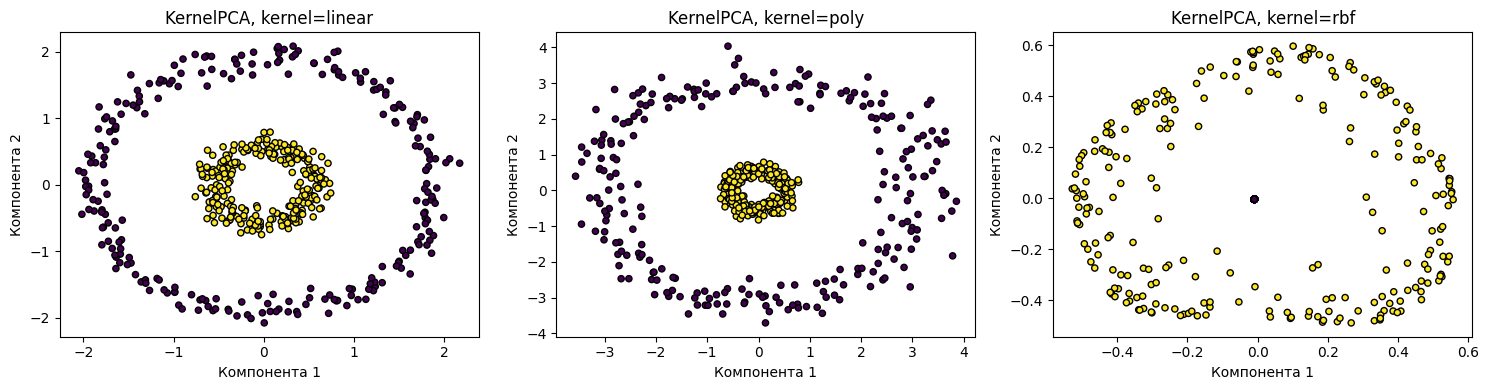

In [13]:
X, y = make_circles(n_samples=500, factor=0.3, noise=0.05, random_state=42)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Исходные данные
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.title('Исходные круги (линейно неразделимые)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.show()

# KernelPCA с разными ядрами
kernels = ['linear', 'poly', 'rbf']
plt.figure(figsize=(15, 4))

for i, kernel in enumerate(kernels):
    kpca = KernelPCA(n_components=2, kernel=kernel, gamma=10 if kernel == 'rbf' else None)
    X_kpca = kpca.fit_transform(X_scaled)
    plt.subplot(1, 3, i+1)
    plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='viridis', edgecolor='k', s=20)
    plt.title(f'KernelPCA, kernel={kernel}')
    plt.xlabel('Компонента 1')
    plt.ylabel('Компонента 2')
plt.tight_layout()
plt.show()

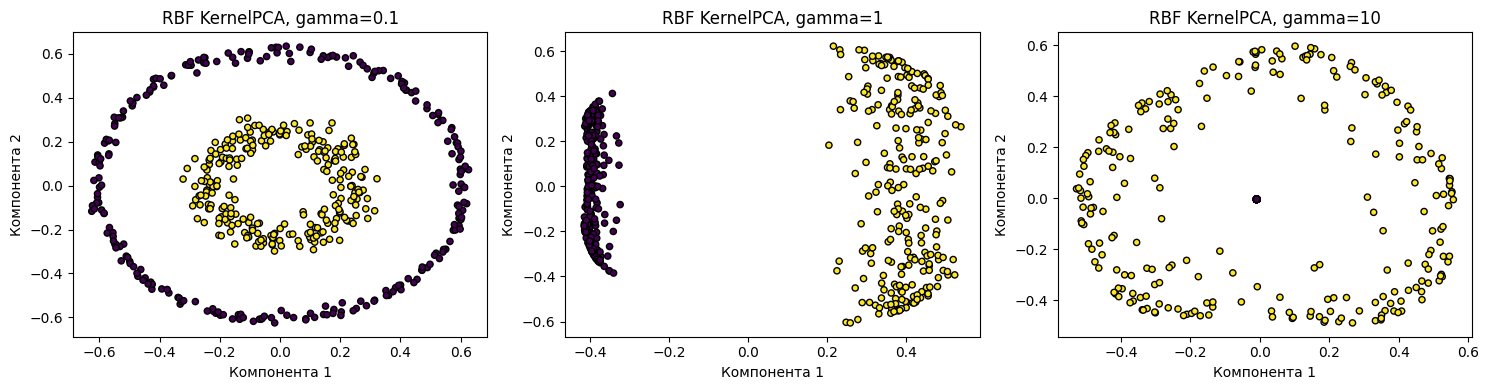

In [14]:
gamma_values = [0.1, 1, 10]
plt.figure(figsize=(15, 4))

for i, gamma in enumerate(gamma_values):
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=gamma)
    X_kpca = kpca.fit_transform(X_scaled)
    plt.subplot(1, 3, i+1)
    plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='viridis', edgecolor='k', s=20)
    plt.title(f'RBF KernelPCA, gamma={gamma}')
    plt.xlabel('Компонента 1')
    plt.ylabel('Компонента 2')
plt.tight_layout()
plt.show()

# Задания для самостоятельного решения

# Задание 1

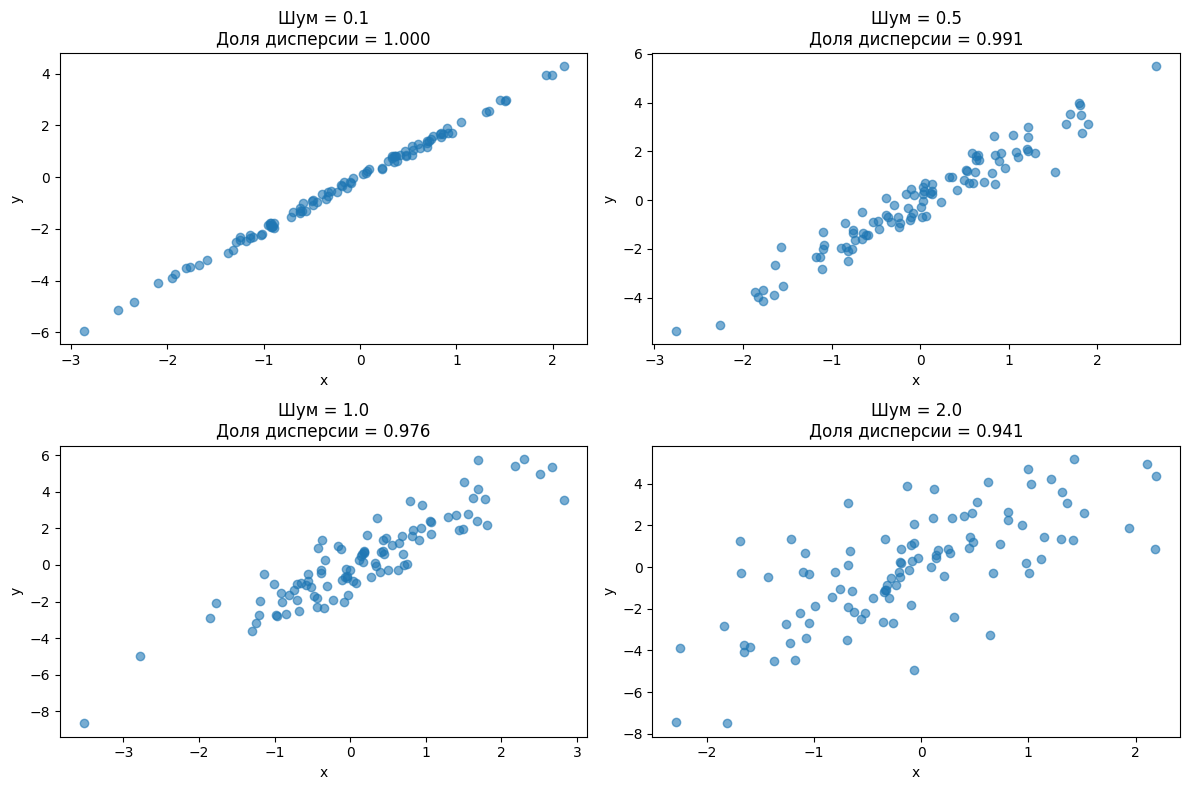

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

noise_levels = [0.1, 0.5, 1.0, 2.0]
plt.figure(figsize=(12, 8))

for i, noise in enumerate(noise_levels):
    x = np.random.normal(0, 1, 100)
    y_noisy = 2 * x + np.random.normal(0, noise, 100)
    X_noisy = np.column_stack((x, y_noisy))
    pca = PCA(n_components=1)
    X_pca = pca.fit_transform(X_noisy)
    
    plt.subplot(2, 2, i+1)
    plt.scatter(x, y_noisy, alpha=0.6)
    plt.title(f'Шум = {noise}\nДоля дисперсии = {pca.explained_variance_ratio_[0]:.3f}')
    plt.xlabel('x')
    plt.ylabel('y')
plt.tight_layout()
plt.show()

# Задание 2

Объяснённая дисперсия каждой компоненты: [0.97860842 0.01945705]
Суммарная объяснённая дисперсия: 0.9980654672368431


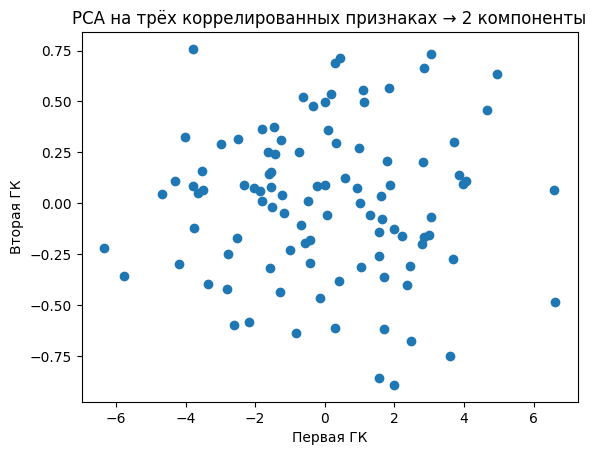

In [16]:
n = 100
x1 = np.random.normal(0, 1, n)
x2 = 2 * x1 + np.random.normal(0, 0.3, n)
x3 = 1.5 * x1 + np.random.normal(0, 0.4, n)
X_3d = np.column_stack((x1, x2, x3))

pca_3d = PCA(n_components=2)
X_pca_3d = pca_3d.fit_transform(X_3d)

print("Объяснённая дисперсия каждой компоненты:", pca_3d.explained_variance_ratio_)
print("Суммарная объяснённая дисперсия:", sum(pca_3d.explained_variance_ratio_))

plt.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1])
plt.title('PCA на трёх коррелированных признаках → 2 компоненты')
plt.xlabel('Первая ГК')
plt.ylabel('Вторая ГК')
plt.show()

# Задание 3

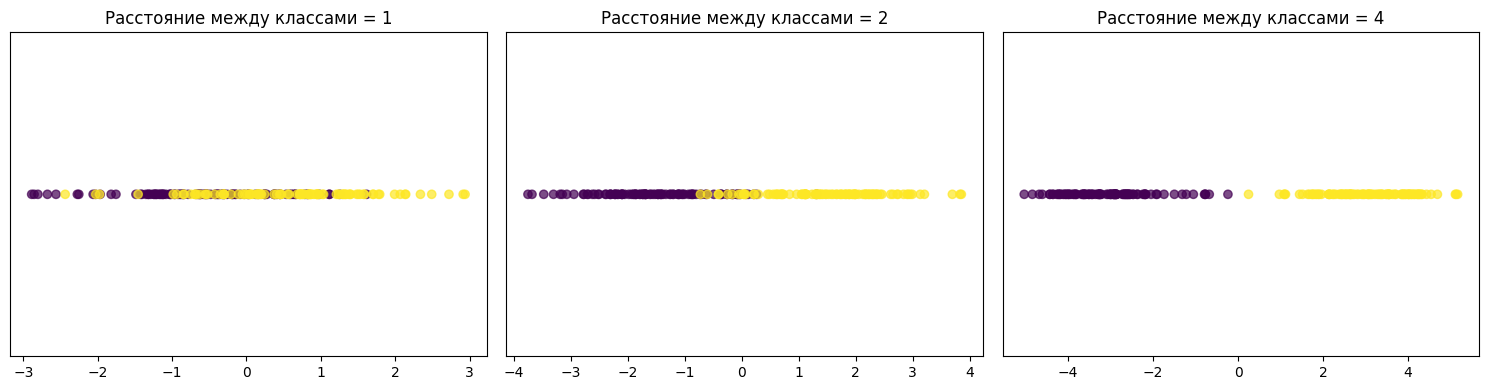

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

distances = [1, 2, 4]
plt.figure(figsize=(15, 4))

for i, d in enumerate(distances):
    x1 = np.random.normal(2, 1, 100)
    y1 = np.random.normal(2, 1, 100)
    x2 = np.random.normal(2 + d, 1, 100)
    y2 = np.random.normal(2 + d, 1, 100)
    X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
    y = np.hstack((np.zeros(100), np.ones(100)))
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    lda = LDA(n_components=1)
    X_lda = lda.fit_transform(X_scaled, y)
    
    plt.subplot(1, 3, i+1)
    plt.scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='viridis', alpha=0.7)
    plt.title(f'Расстояние между классами = {d}')
    plt.yticks([])
plt.tight_layout()
plt.show()

# Задание 4

Объяснённая дисперсия компонент LDA: [0.75945195 0.24054805]


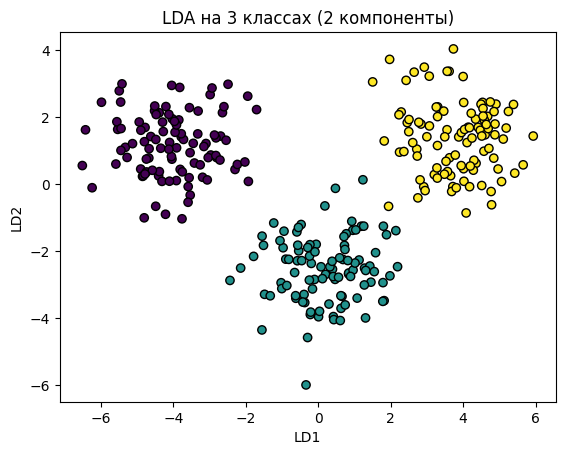

In [18]:
n = 100
x1 = np.random.normal(0, 1, n)
y1 = np.random.normal(0, 1, n)
x2 = np.random.normal(4, 1, n)
y2 = np.random.normal(4, 1, n)
x3 = np.random.normal(8, 1, n)
y3 = np.random.normal(0, 1, n)

X_3cls = np.vstack((np.column_stack((x1, y1)), 
                    np.column_stack((x2, y2)), 
                    np.column_stack((x3, y3))))
y_3cls = np.hstack((np.zeros(n), np.ones(n), 2*np.ones(n)))

scaler = StandardScaler()
X_scaled_3 = scaler.fit_transform(X_3cls)
lda_3 = LDA(n_components=2)
X_lda_3 = lda_3.fit_transform(X_scaled_3, y_3cls)

print("Объяснённая дисперсия компонент LDA:", lda_3.explained_variance_ratio_)
plt.scatter(X_lda_3[:, 0], X_lda_3[:, 1], c=y_3cls, cmap='viridis', edgecolor='k')
plt.title('LDA на 3 классах (2 компоненты)')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.show()

# Задание 5

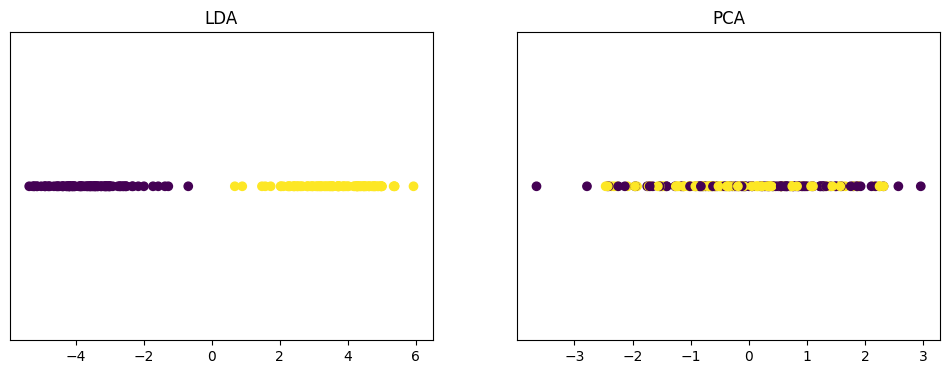

In [19]:
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA

X, y = make_blobs(n_samples=200, random_state=170, centers=2)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X = np.dot(X, transformation)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LDA
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

# PCA
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_lda, np.zeros_like(X_lda), c=y, cmap='viridis')
axes[0].set_title('LDA')
axes[1].scatter(X_pca, np.zeros_like(X_pca), c=y, cmap='viridis')
axes[1].set_title('PCA')
axes[0].set_yticks([])
axes[1].set_yticks([])
plt.show()

# Задание 6

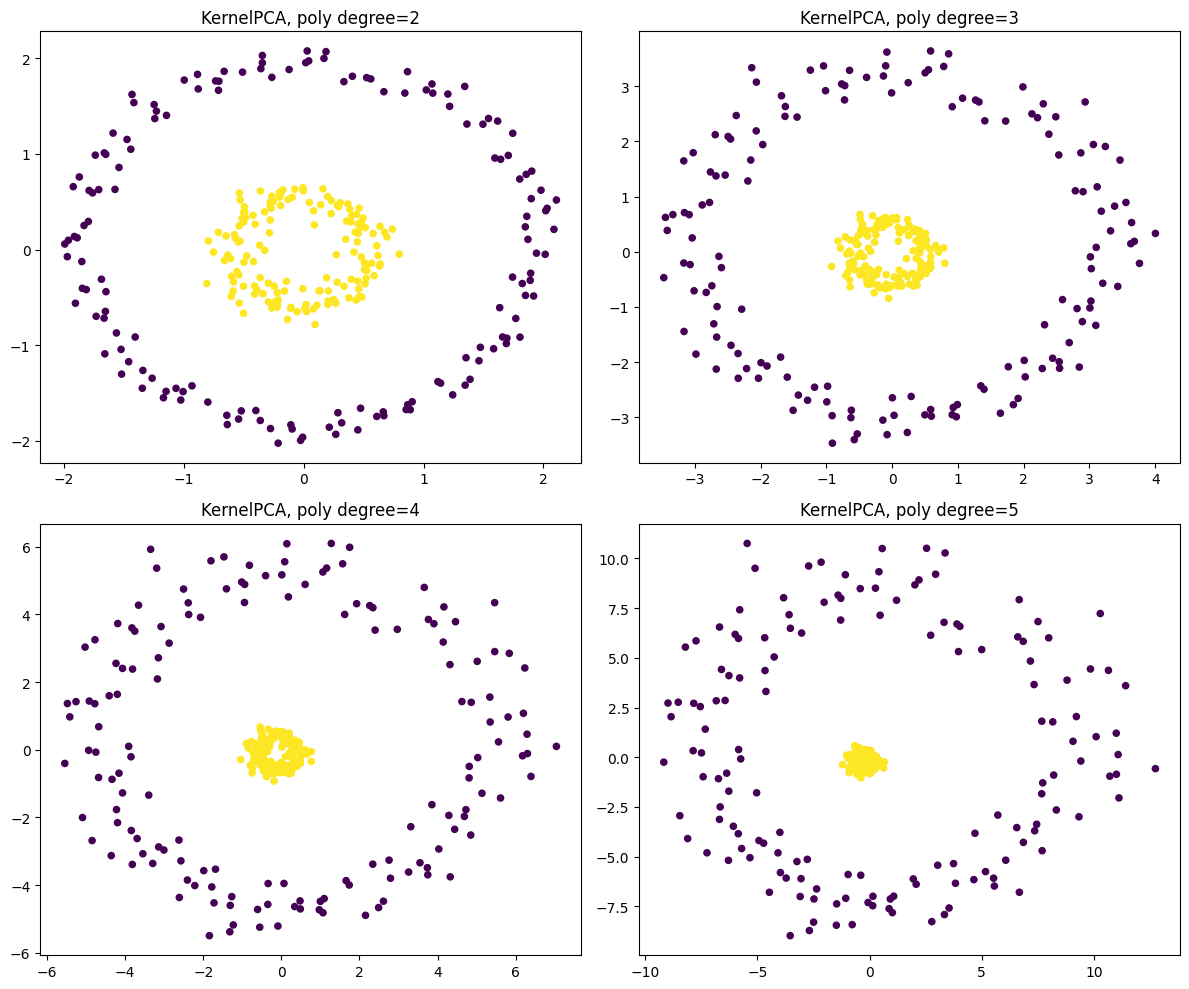

In [20]:
from sklearn.decomposition import KernelPCA
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=300, factor=0.3, noise=0.05, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

degrees = [2, 3, 4, 5]
plt.figure(figsize=(12, 10))
for i, deg in enumerate(degrees):
    kpca = KernelPCA(n_components=2, kernel='poly', degree=deg)
    X_kpca = kpca.fit_transform(X_scaled)
    plt.subplot(2, 2, i+1)
    plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='viridis', s=20)
    plt.title(f'KernelPCA, poly degree={deg}')
plt.tight_layout()
plt.show()

# Задание 7

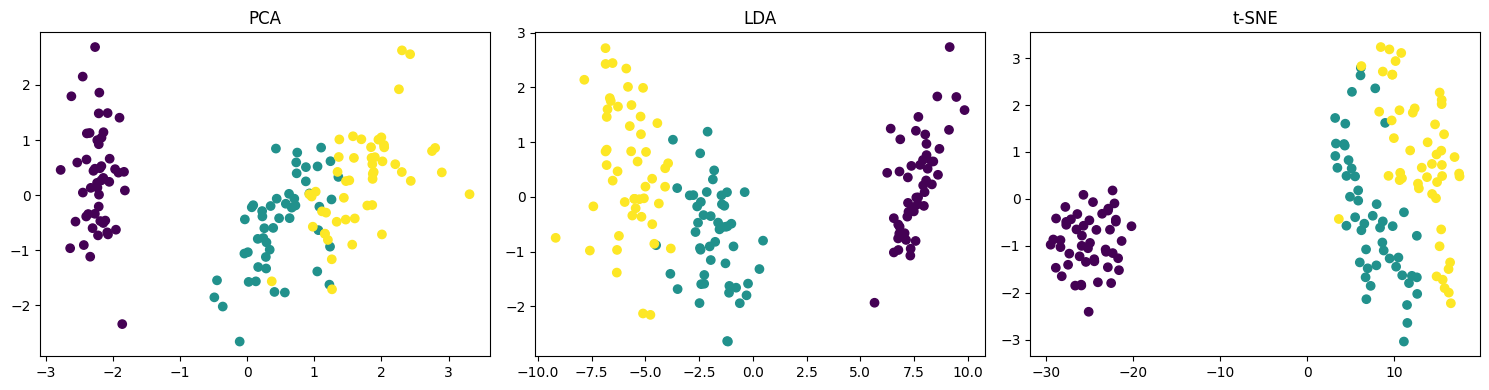

In [21]:
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE

iris = load_iris()
X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca_iris = PCA(n_components=2)
X_pca_iris = pca_iris.fit_transform(X_scaled)

# LDA
lda_iris = LDA(n_components=2)
X_lda_iris = lda_iris.fit_transform(X_scaled, y)

# t-SNE
tsne_iris = TSNE(n_components=2, random_state=42)
X_tsne_iris = tsne_iris.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(X_pca_iris[:, 0], X_pca_iris[:, 1], c=y, cmap='viridis')
axes[0].set_title('PCA')
axes[1].scatter(X_lda_iris[:, 0], X_lda_iris[:, 1], c=y, cmap='viridis')
axes[1].set_title('LDA')
axes[2].scatter(X_tsne_iris[:, 0], X_tsne_iris[:, 1], c=y, cmap='viridis')
axes[2].set_title('t-SNE')
plt.tight_layout()
plt.show()

# Задание 8

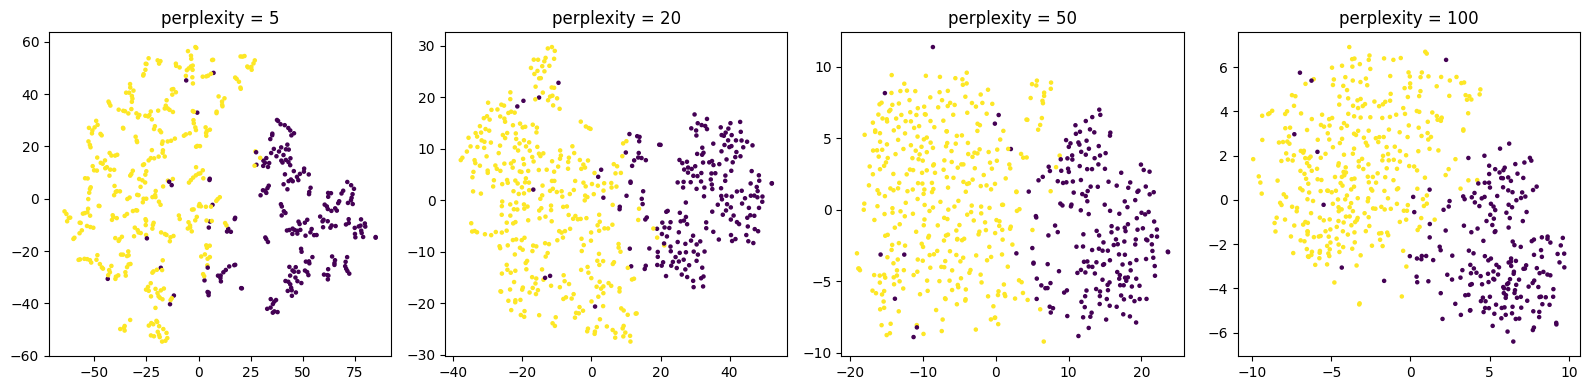

In [22]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

perplexities = [5, 20, 50, 100]
plt.figure(figsize=(16, 4))
for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    plt.subplot(1, 4, i+1)
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', s=5)
    plt.title(f'perplexity = {perp}')
plt.tight_layout()
plt.show()

# Задание 9 (сделал в 7-м)

# Задание 10

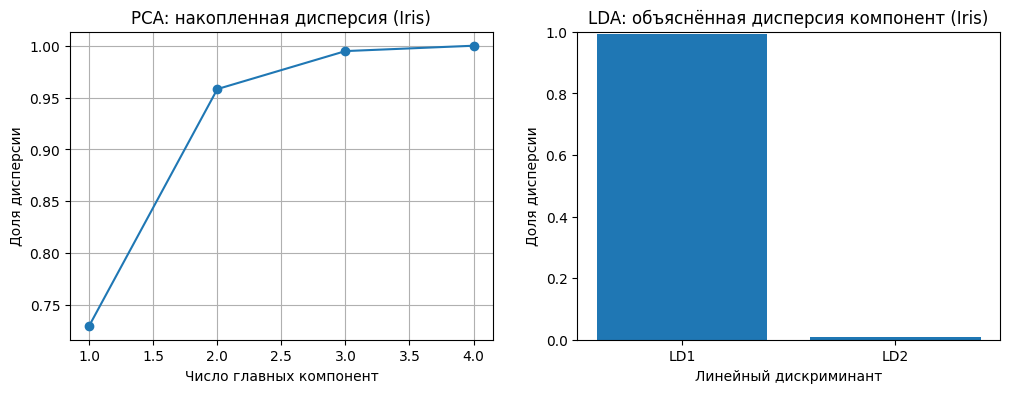

Оптимальное число компонент для PCA: примерно 2 (локоть на графике).
LDA: объяснённая дисперсия компонент: [0.9912126 0.0087874]


In [25]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Загружаем датасет ирисов (3 класса)
iris = load_iris()
X = iris.data
y = iris.target

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- PCA: накопленная дисперсия ---
pca_full = PCA()
pca_full.fit(X_scaled)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(cumsum)+1), cumsum, marker='o')
plt.title('PCA: накопленная дисперсия (Iris)')
plt.xlabel('Число главных компонент')
plt.ylabel('Доля дисперсии')
plt.grid(True)

# --- LDA: объяснённая дисперсия компонент ---
lda_full = LDA()
lda_full.fit(X_scaled, y)
lda_ev = lda_full.explained_variance_ratio_

plt.subplot(1, 2, 2)
plt.bar(range(1, len(lda_ev)+1), lda_ev, tick_label=[f'LD{i}' for i in range(1, len(lda_ev)+1)])
plt.title('LDA: объяснённая дисперсия компонент (Iris)')
plt.xlabel('Линейный дискриминант')
plt.ylabel('Доля дисперсии')
plt.ylim(0, 1)
plt.show()

print("Оптимальное число компонент для PCA: примерно 2 (локоть на графике).")
print(f"LDA: объяснённая дисперсия компонент: {lda_ev}")

# Задание 11

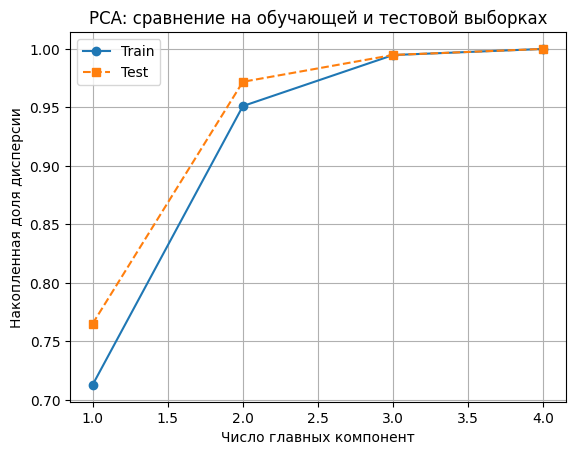

После 2 компонент: на train – 0.951, на test – 0.972


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

# Данные
iris = load_iris()
X = iris.data
y = iris.target   # y не используется в PCA, но для разбиения нужен

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# PCA на обучающей выборке
pca = PCA()
pca.fit(X_train)

# Накопленная дисперсия на train
cumsum_train = np.cumsum(pca.explained_variance_ratio_)

# Проецируем тестовые данные на компоненты, полученные на train
X_test_pca = pca.transform(X_test)
# Дисперсия проекций на тесте
test_var = np.var(X_test_pca, axis=0, ddof=1)
# Общая дисперсия тестовых данных (сумма дисперсий по исходным признакам)
total_test_var = np.var(X_test, axis=0, ddof=1).sum()
# Доля дисперсии каждой компоненты на тесте
explained_test = test_var / total_test_var
cumsum_test = np.cumsum(explained_test)

# График
plt.plot(range(1, len(cumsum_train)+1), cumsum_train, 'o-', label='Train')
plt.plot(range(1, len(cumsum_test)+1), cumsum_test, 's--', label='Test')
plt.xlabel('Число главных компонент')
plt.ylabel('Накопленная доля дисперсии')
plt.title('PCA: сравнение на обучающей и тестовой выборках')
plt.legend()
plt.grid(True)
plt.show()

print(f"После 2 компонент: на train – {cumsum_train[1]:.3f}, на test – {cumsum_test[1]:.3f}")